# 📌 Credit Risk / Loan Default Decisioning System  
### End-to-End, Business-First Analytics Project

---

## 🔍 Project Overview

This notebook implements an **end-to-end credit risk decisioning pipeline** using historical loan data.  
The objective is **not just to predict loan default**, but to **support real lending decisions** such as:

- ✅ Approve  
- 🟡 Manual Review  
- ❌ Reject  

The project is designed to closely mirror how **risk analytics teams in banks and fintech companies** build, evaluate, and operationalize credit risk models — with a strong emphasis on **business impact, explainability, and decision-making**.

---

## 🎯 Business Problem

Lending decisions involve **asymmetric risk**:

- Approving a bad borrower can lead to **significant financial loss**
- Rejecting a good borrower leads to **missed revenue and customer churn**

The goal of this project is to:

> **Estimate the probability of loan default for each applicant and translate that risk into actionable business decisions aligned with risk appetite.**

---

## 🧠 Key Design Principles

This project follows **real-world analytics best practices**:

- **Business-first thinking**  
  Models output probabilities; decisions are made via business rules.

- **Clear separation of concerns**
  - Data ingestion & hygiene  
  - Feature engineering  
  - Modeling  
  - Evaluation  
  - Decisioning  

- **Leakage prevention**  
  Only information available at loan decision time is used.

- **Cost-sensitive evaluation**  
  Models are compared using expected financial loss, not just accuracy.

- **Explainability & governance**  
  Interpretable features and baseline models are retained for auditability.

---

## 🗂 Dataset

- **Source**: Lending Club loan performance dataset (via Kaggle)
- **Nature**: Historical consumer loan data
- **Target Variable**: Binary default outcome  
  - `1` → Default (Charged Off / Defaulted)  
  - `0` → Non-default (Fully Paid)  

⚠️ Due to dataset size, **data ingestion, cleaning, and feature engineering are executed inside Kaggle** to leverage higher memory availability.

---

## 🧱 Pipeline Structure (High-Level)

The notebook is organized into **clear, sequential phases**, each answering a specific business question:

1. **Phase 1 – Data Ingestion**  
   Secure, chunk-based loading of raw loan data.

2. **Phase 2 – Data Cleaning & Hygiene**  
   - Binary target definition  
   - Leakage prevention  
   - Missing value handling  

3. **Phase 3 – Feature Engineering**  
   Creation of interpretable risk signals capturing:
   - Repayment capacity  
   - Credit history strength  
   - Loan structure stress  

4. **Phase 4 – Modeling**  
   - Baseline: Logistic Regression  
   - Advanced: Random Forest  
   Models produce **probability of default (PD)**, not hard decisions.

5. **Phase 5 – Evaluation & Business Trade-offs**  
   - ROC-AUC and Precision–Recall  
   - Confusion matrices at business thresholds  
   - Cost-sensitive model comparison  

6. **Phase 6 – Decision Engine**  
   Conversion of PDs into:
   - Approve  
   - Review  
   - Reject  

7. **Phase 7 – Interview & Business Packaging**  
   Final articulation of insights, trade-offs, and impact.

---

## 📊 Key Outputs

This notebook produces **business-ready artifacts**, including:

- Probability of default (PD) per loan
- Risk band assignment (Low / Medium / High)
- Approval, review, or rejection decisions
- Portfolio-level default rates
- Expected financial loss comparison across models
- Final decision dataset suitable for operations or dashboards

---

## 🏦 How This Would Be Used in Practice

In a real lending environment:

- Models score applications in real time
- Risk thresholds are controlled by business and risk teams
- Policies can be tightened or relaxed **without retraining models**
- Logistic regression serves as a governance benchmark
- Tree-based models provide enhanced risk separation

---

## 🎤 One-Line Interview Explanation

> “This project builds a full credit risk decisioning system that predicts default probability and converts it into real lending actions using business-controlled thresholds and cost-based evaluation.”

---

## ⚠️ Important Notes

- This notebook prioritizes **decision realism over leaderboard optimization**
- All features are decision-time realistic and explainable
- The project is intentionally designed to be **interview-ready for analytics and consulting roles**


# **Setup and Imports**  

In [13]:
import pandas as pd
import numpy as np
import os

# **PHASE 1: DATA INGESTION**

In [14]:
DATA_PATH = "/kaggle/input/lending-club/accepted_2007_to_2018Q4.csv.gz"

chunk_size = 200_000  # safe chunk size
chunks = []

for chunk in pd.read_csv(DATA_PATH, compression="gzip", chunksize=chunk_size, low_memory=False):
    chunks.append(chunk)

raw_df = pd.concat(chunks, ignore_index=True)

print("Raw data loaded")
print("Shape:", raw_df.shape)


Raw data loaded
Shape: (2260701, 151)


# **PHASE 2: DATA CLEANING & LEAKAGE PREVENTION**

## Step 1: Define Binary Target

In [15]:
valid_status = ["Fully Paid", "Charged Off", "Default"]

raw_df = raw_df[raw_df["loan_status"].isin(valid_status)]

raw_df["default_flag"] = raw_df["loan_status"].apply(
    lambda x: 1 if x in ["Charged Off", "Default"] else 0
)


## Step 2: Remove Leakage Columns

In [16]:
leakage_cols = [
    "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int",
    "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt",
    "next_pymnt_d"
]

raw_df.drop(columns=[c for c in leakage_cols if c in raw_df.columns],
            inplace=True)


## Step 3: Handle Missing Values (SAFE & EXPLAINABLE)

In [17]:
if "annual_inc" in raw_df.columns:
    raw_df["annual_inc"] = raw_df["annual_inc"].fillna(
       raw_df["annual_inc"].median()
    )

if "emp_length" in raw_df.columns:
    raw_df["emp_length"] = raw_df["emp_length"].fillna("Unknown")


## Step 4: Drop High-Missing Columns

In [18]:
missing_ratio = raw_df.isnull().mean()
high_missing = missing_ratio[missing_ratio > 0.5].index

raw_df.drop(columns=high_missing, inplace=True)


## Final Sanity Check

In [19]:
print("Cleaned data shape:", raw_df.shape)
print("Default rate:", raw_df["default_flag"].mean())


Cleaned data shape: (1345350, 86)
Default rate: 0.19964990522912254


## SAVE CLEANED OUTPUT

In [20]:
OUTPUT_PATH = "/kaggle/working/cleaned_data.csv"
raw_df.to_csv(OUTPUT_PATH, index=False)

print("Cleaned data saved.")


Cleaned data saved.


# **PHASE 3 — FEATURE ENGINEERING**

## i. LOAD CLEANED DATA

In [21]:


CLEAN_PATH = "/kaggle/working/cleaned_data.csv"
df = pd.read_csv(CLEAN_PATH)

print(df.shape)


(1345350, 86)


## ii. FEATURE ENGINEERING

We’ll create three categories of features:

1. Capacity to repay

2. Credit behavior

3. Loan structure stress

Each feature has a clear business meaning.

#### 1. Capacity to Repay

In [22]:
#▶️ Income-to-Loan Ratio
df["income_to_loan_ratio"] = df["annual_inc"] / df["loan_amnt"]

# ▶️ Installment Burden (Monthly Stress)
df["installment_to_income"] = df["installment"] / (df["annual_inc"] / 12)

#### 2. Credit History Strength

In [23]:
#▶️ Credit Age (Experience)
if "earliest_cr_line" in df.columns:
    df["earliest_cr_line"] = pd.to_datetime(
        df["earliest_cr_line"],
        format="%b-%Y",
        errors="coerce"
    )

    df["credit_history_years"] = (
        pd.Timestamp("2018-12-31") - df["earliest_cr_line"]
    ).dt.days / 365


#▶️ Revolving Utilization (Risk Signal)
if "revol_util" in df.columns:
    df["revol_util"] = (
        df["revol_util"]
        .astype(str)                 # ensure string
        .str.replace("%", "", regex=False)
    )

    df["revol_util"] = pd.to_numeric(
        df["revol_util"],
        errors="coerce"
    )


#### 3. Loan Structure Risk

In [24]:
#▶️ Loan Term Encoding
if "term" in df.columns:
    df["term_months"] = (
        df["term"]
        .astype(str)
        .str.extract(r"(\d+)")
    )

    df["term_months"] = pd.to_numeric(
        df["term_months"],
        errors="coerce"
    )


#▶️ Interest Rate (Already a Risk Proxy)
if "int_rate" in df.columns:
    df["int_rate"] = (
        df["int_rate"]
        .astype(str)                 # force string safely
        .str.replace("%", "", regex=False)
    )

    df["int_rate"] = pd.to_numeric(
        df["int_rate"],
        errors="coerce"
    )



#### 4. Delinquency Flags (STRONG SIGNALS)

In [25]:
df["has_delinquency"] = (
    (df["delinq_2yrs"] > 0) |
    (df["pub_rec"] > 0)
).astype(int)


## iii. BASIC CATEGORICAL CLEANUP

In [26]:
categorical_cols = [
    "grade", "sub_grade", "home_ownership",
    "verification_status", "purpose"
]

df[categorical_cols] = df[categorical_cols].astype("category")


## iv. FINAL FEATURE SELECTION
We now drop columns we will not use.

Why?

Reduce memory

Reduce noise

Improve explainability

In [27]:
features_to_keep = [
    "loan_amnt", "annual_inc", "installment",
    "income_to_loan_ratio", "installment_to_income",
    "credit_history_years", "revol_util",
    "int_rate", "term_months",
    "has_delinquency",
    "grade", "sub_grade", "home_ownership",
    "verification_status", "purpose",
    "default_flag"
]

df_model = df[features_to_keep].copy()

print(df_model.shape)


(1345350, 16)


## v. SAVE MODEL-READY DATASET

In [28]:
MODEL_DATA_PATH = "/kaggle/working/model_input.csv"
df_model.to_csv(MODEL_DATA_PATH, index=False)

print("Model-ready dataset saved.")



Model-ready dataset saved.


# **PHASE 4 — MODELING**

## i. LOAD MODEL-READY DATA

In [41]:
MODEL_DATA_PATH = "/kaggle/working/model_input.csv"
df_model = pd.read_csv(MODEL_DATA_PATH)

print(df_model.shape)
df_model.head()

(1345350, 16)


,loan_amnt,annual_inc,installment,income_to_loan_ratio,installment_to_income,credit_history_years,revol_util,int_rate,term_months,has_delinquency,grade,sub_grade,home_ownership,verification_status,purpose,default_flag
0,3600.0,55000.0,123.03,15.277778,0.026843,15.427397,29.7,13.99,36,0,C,C4,MORTGAGE,Not Verified,debt_consolidation,0
1,24700.0,65000.0,820.28,2.631579,0.151436,19.095890,19.2,11.99,36,1,C,C1,MORTGAGE,Not Verified,small_business,0
2,20000.0,63000.0,432.66,3.150000,0.082411,18.427397,56.2,10.78,60,0,B,B4,MORTGAGE,Not Verified,home_improvement,0
3,10400.0,104433.0,289.91,10.041635,0.033312,20.597260,64.5,22.45,60,1,F,F1,MORTGAGE,Source Verified,major_purchase,0
4,11950.0,34000.0,405.18,2.845188,0.143005,31.271233,68.4,13.44,36,0,C,C3,RENT,Source Verified,debt_consolidation,0


### Model hygiene (MANDATORY)
##### ValueError: Input X contains infinity or a value too large for dtype('float64')

This tells us:

> Some numeric features contain ∞ (infinity) or extreme values, and Logistic Regression refuses to train on them.
>
##### ✅ THE CORRECT FIX:


In [42]:
# STEP 1 -- REPLACE inf WITH NaN
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

# STEP 2 — HANDLE REMAINING MISSING VALUES (NUMERIC ONLY)
## Numeric columns only
numeric_cols = df_model.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# STEP 3 — FINAL SANITY CHECK (CRITICAL)
print("Any NaNs left?", df_model.isnull().any().any())
print("Any infinities left?", np.isinf(df_model.select_dtypes(include=["float64"])).any().any())


Any NaNs left? False
Any infinities left? False


## ii. TRAIN–TEST SPLIT (RISK-SAFE)
🎯 Why this matters

In credit risk:

We care about out-of-sample performance

Default rate must be preserved

So we use stratified split.

In [43]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["default_flag"])
y = df_model["default_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Train default rate:", y_train.mean())
print("Test default rate :", y_test.mean())
# 👉 If these two numbers are similar, your split is correct.

Train default rate: 0.19964975639536497
Test default rate : 0.1996503517295102


## iii. PREPROCESSING PIPELINE

In [44]:
# Identify column types
categorical_cols = X.select_dtypes(include=["category", "object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()


In [45]:
# Build preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


This pipeline is:

* Clean

* Reusable

* Production-style

## iv. BASELINE MODEL: LOGISTIC REGRESSION

##### 🎯 Why Logistic Regression?

Because in credit risk:

*  It’s interpretable

* It’s regulator-friendly

* It sets the minimum bar

* ### Train Logistic Model

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

log_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['loan_amnt', 'annual_inc',
                                                   'installment',
                                                   'income_to_loan_ratio',
                                                   'installment_to_income',
                                                   'credit_history_years',
                                                   'revol_util', 'int_rate',
                                                   'term_months',
                                                   'has_delinquency']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['grade', 'sub_grade',
                                                   'home_ownership',
                                                   'verification_status',
                                                   'purpose'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [47]:
# Predict Probabilities
y_pred_log = log_model.predict_proba(X_test)[:, 1]


## v. ADVANCED MODEL: RANDOM FOREST

##### 🎯 Why Random Forest?

* Captures non-linear risk patterns

* Strong benchmark

* Still explainable at a high level

In [48]:
# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=50,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['loan_amnt', 'annual_inc',
                                                   'installment',
                                                   'income_to_loan_ratio',
                                                   'installment_to_income',
                                                   'credit_history_years',
                                                   'revol_util', 'int_rate',
                                                   'term_months',
                                                   'has_delinquency']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['grade', 'sub_grade',
                                                   'home_ownership',
                                                   'verification_status',
                                                   'purpose'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=50,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

We **intentionally restrict depth**:

* Prevent overfitting

* Improve stability

* Easier to justify to business

In [49]:
# Predict Probabilities
y_pred_rf = rf_model.predict_proba(X_test)[:, 1]


## vi. SAVE MODELS & PREDICTIONS

These artifacts are needed for Phase 5 (Evaluation & Decisions).

In [50]:
import joblib
import os

os.makedirs("/kaggle/working/models", exist_ok=True)

joblib.dump(log_model, "/kaggle/working/models/logistic_model.pkl")
joblib.dump(rf_model, "/kaggle/working/models/random_forest_model.pkl")

predictions = pd.DataFrame({
    "actual_default": y_test.values,
    "logistic_pd": y_pred_log,
    "rf_pd": y_pred_rf
})

predictions.to_csv("/kaggle/working/model_predictions.csv", index=False)

print("Models and predictions saved.")


Models and predictions saved.


# **PHASE 5 — MODEL EVALUATION & BUSINESS TRADE-OFFS**
###
#### 🎯 PHASE 5 GOAL (BUSINESS LENS)

> “Given two risk models, which one saves more money for the lender at a given risk appetite?”

Important:

* We do not judge models on accuracy alone

* We evaluate ranking quality, mistake costs, and decision impact

This is exactly how risk committees think.

## i. LOAD MODEL PREDICTIONS

In [51]:
preds = pd.read_csv("/kaggle/working/model_predictions.csv")
preds.head()

,actual_default,logistic_pd,rf_pd
0,1,0.444183,0.182160
1,0,0.600737,0.241131
2,0,0.566108,0.256440
3,0,0.368860,0.140985
4,0,0.717254,0.392682


## ii. TECHNICAL EVALUATION (RANKING QUALITY)
#####
#### 🎯 Why ROC-AUC?

* Measures how well the model ranks risky vs safe borrowers

* Threshold-independent

* Industry standard in credit risk

In [52]:
# ROC-AUC Comparison
from sklearn.metrics import roc_auc_score

roc_log = roc_auc_score(preds["actual_default"], preds["logistic_pd"])
roc_rf  = roc_auc_score(preds["actual_default"], preds["rf_pd"])

print(f"ROC-AUC (Logistic): {roc_log:.3f}")
print(f"ROC-AUC (Random Forest): {roc_rf:.3f}")


ROC-AUC (Logistic): 0.704
ROC-AUC (Random Forest): 0.704


How to interpret:

0.50 → random guessing

0.70+ → decent credit model

0.75+ → strong

## iii. PRECISION–RECALL (DEFAULT-FOCUSED)
#####

Defaults are rare, so PR matters.

> 📌 Higher PR = fewer bad loans slipping through.

In [53]:
from sklearn.metrics import average_precision_score

pr_log = average_precision_score(preds["actual_default"], preds["logistic_pd"])
pr_rf  = average_precision_score(preds["actual_default"], preds["rf_pd"])

print(f"Avg Precision (Logistic): {pr_log:.3f}")
print(f"Avg Precision (Random Forest): {pr_rf:.3f}")


Avg Precision (Logistic): 0.361
Avg Precision (Random Forest): 0.365


## iv. CONFUSION MATRIX AT BUSINESS THRESHOLDS

#### Define Business Threshold

Let’s assume:

* Reject if PD ≥ 0.70

* Everything else approved (for simplicity)

In [54]:
THRESHOLD = 0.7

preds["logistic_decision"] = (preds["logistic_pd"] >= THRESHOLD).astype(int)
preds["rf_decision"]       = (preds["rf_pd"] >= THRESHOLD).astype(int)


### Confusion Matrices

In [55]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(preds["actual_default"], preds["logistic_decision"])
cm_rf  = confusion_matrix(preds["actual_default"], preds["rf_decision"])

print("Logistic Confusion Matrix:\n", cm_log)
print("\nRandom Forest Confusion Matrix:\n", cm_rf)


Logistic Confusion Matrix:
 [[250853  18335]
 [ 52703  14447]]

Random Forest Confusion Matrix:
 [[269188      0]
 [ 67150      0]]


### INTERPRETATION: CONFUSION MATRIX FORMAT (NUMERIC TRUTH)

*sklearn.confusion_matrix(y_true, y_pred) returns:*

##### [[TN FP]
##### [FN TP]]


>FP = Good borrower rejected (lost revenue)

>FN = Bad borrower approved (credit loss)

### LET’S FIX THE CONFUSION ABOUT FP / FN (IMPORTANT)

You’re right to call this out — there was a notation slip earlier.
So let’s reset cleanly and lock the definitions once and for all.

In a credit default model where

Target = 1 means DEFAULT (bad borrower)

#### Term-------------------Meaning-------------------------------Business impact
##### TP-----------Default borrower correctly predicted as default-----------✅ Loss avoided
##### TN-----------Good borrower correctly approved------------------------✅ Revenue earned
##### FP-----------Good borrower predicted as default-----------------------❌ Lost revenue
##### FN-----------Default borrower predicted as good------------------------❌ Credit loss

👉 FP = wrong rejection
👉 FN = wrong approval

This mapping is correct and final.

## v. COST-SENSITIVE EVALUATION (MOST IMPORTANT)
#### 🔹 Define Business Costs (Example)

Let’s assume:

* False Negative (missed default) = ₹100,000 loss

* False Positive (wrong rejection) = ₹10,000 opportunity loss

In [61]:
COST_FN = 100_000
COST_FP = 10_000


#### 🔹 Compute Total Expected Loss

In [62]:
def expected_loss(cm, cost_fn, cost_fp):
    tn, fp, fn, tp = cm.ravel()
    return (fn * cost_fn) + (fp * cost_fp)

loss_log = expected_loss(cm_log, COST_FN, COST_FP)
loss_rf  = expected_loss(cm_rf, COST_FN, COST_FP)

print(f"Expected Loss (Logistic): ₹{loss_log:,}")
print(f"Expected Loss (Random Forest): ₹{loss_rf:,}")


Expected Loss (Logistic): ₹5,453,650,000
Expected Loss (Random Forest): ₹6,715,000,000


# **PHASE 6 — DECISION ENGINE**
###
#### 🎯 PHASE 6 GOAL (BUSINESS-FIRST)

>Convert model probabilities into Approve / Review / Reject decisions using business-controlled thresholds, and quantify the impact.

Key principle (LOCK THIS):

* Models predict risk

* Policies make decisions

This separation is non-negotiable in real credit systems.

#### 🧠 WHY A DECISION ENGINE IS A SEPARATE PHASE
#### “Why not just use 0.5 cutoff?”

>“Because lending decisions depend on risk appetite, not statistical symmetry.”

Different businesses → different thresholds → same model.

That’s why this phase exists.

## i. LOAD PREDICTIONS (AGAIN)

In [56]:
# We’ll continue using the predictions from Phase 5.
preds = pd.read_csv("/kaggle/working/model_predictions.csv")
preds.head()

,actual_default,logistic_pd,rf_pd
0,1,0.444183,0.182160
1,0,0.600737,0.241131
2,0,0.566108,0.256440
3,0,0.368860,0.140985
4,0,0.717254,0.392682


## ii. DEFINE BUSINESS RISK BANDS
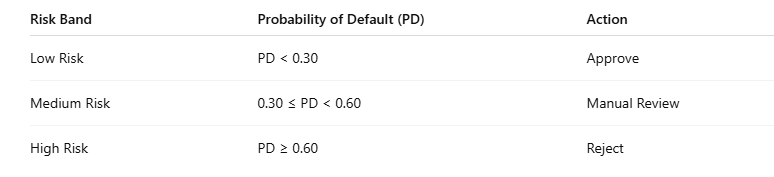
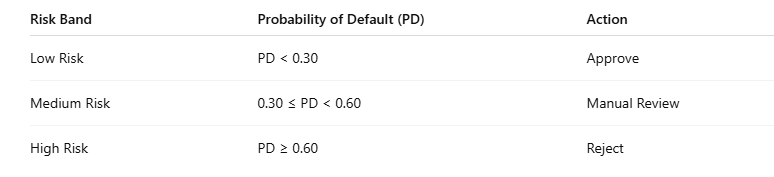

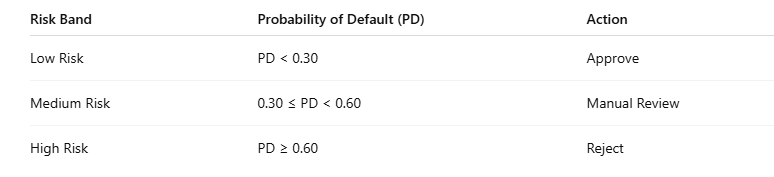


In [72]:
#These are illustrative, not universal.
LOW_RISK_TH = 0.40
HIGH_RISK_TH = 0.50


## iii. APPLY DECISION RULES

In [73]:
#Decision Logic (Reusable)
def assign_decision(pd_value, low_th, high_th):
    if pd_value < low_th:
        return "Approve"
    elif pd_value < high_th:
        return "Review"
    else:
        return "Reject"


In [74]:
# Apply to Both Models
preds["logistic_decision"] = preds["logistic_pd"].apply(
    lambda x: assign_decision(x, LOW_RISK_TH, HIGH_RISK_TH)
)

preds["rf_decision"] = preds["rf_pd"].apply(
    lambda x: assign_decision(x, LOW_RISK_TH, HIGH_RISK_TH)
)


##  iv. PORTFOLIO-LEVEL IMPACT ANALYSIS

#### 1. Decision Distribution

In [75]:
def decision_summary(series):
    return series.value_counts(normalize=True) * 100

print("Logistic Decisions (%):")
print(decision_summary(preds["logistic_decision"]))

print("\nRandom Forest Decisions (%):")
print(decision_summary(preds["rf_decision"]))


Logistic Decisions (%):
logistic_decision
Reject     44.233479
Approve    37.328818
Review     18.437703
Name: proportion, dtype: float64

Random Forest Decisions (%):
rf_decision
Approve    94.484120
Review      5.034816
Reject      0.481064
Name: proportion, dtype: float64


#### 2. Default Rate by Decision Bucket (CRITICAL)
This tells us how clean each bucket is.


In [77]:

def default_rate_by_bucket(df, decision_col):
    return (
        df.groupby(decision_col)["actual_default"]
        .mean()
        .sort_values()
    )

print("Logistic Default Rate by Decision:")
print(default_rate_by_bucket(preds, "logistic_decision"))

print("\nRandom Forest Default Rate by Decision:")
print(default_rate_by_bucket(preds, "rf_decision"))

Logistic Default Rate by Decision:
logistic_decision
Approve    0.087192
Review     0.170255
Reject     0.306808
Name: actual_default, dtype: float64

Random Forest Default Rate by Decision:
rf_decision
Approve    0.182783
Review     0.480394
Reject     0.574166
Name: actual_default, dtype: float64


#### Interpretation (THIS IS IMPORTANT)

You should expect:

* Approve bucket → lowest default rate

* Review bucket → medium

* Reject bucket → highest

If not:
👉 thresholds need adjustment, not the model.

## v. BUSINESS COST AT DECISION LEVEL

Let’s now quantify money.

In [66]:
# Assumptions (Same as Phase 5)
COST_DEFAULT = 100_000      # bad loan approved
COST_REJECT_GOOD = 10_000  # good loan rejected


In [67]:
# Cost Calculation Function
def portfolio_cost(df, decision_col):
    cost = 0

    # Approved bad loans → FN
    approved_bad = df[
        (df[decision_col] == "Approve") &
        (df["actual_default"] == 1)
    ].shape[0]

    # Rejected good loans → FP
    rejected_good = df[
        (df[decision_col] == "Reject") &
        (df["actual_default"] == 0)
    ].shape[0]

    cost += approved_bad * COST_DEFAULT
    cost += rejected_good * COST_REJECT_GOOD

    return cost


In [78]:
# Compare Models
log_cost = portfolio_cost(preds, "logistic_decision")
rf_cost  = portfolio_cost(preds, "rf_decision")

print(f"Total Expected Cost (Logistic): ₹{log_cost:,}")
print(f"Total Expected Cost (Random Forest): ₹{rf_cost:,}")


Total Expected Cost (Logistic): ₹2,125,990,000
Total Expected Cost (Random Forest): ₹5,815,490,000


## vi. FINAL DECISION OUTPUT

In [80]:
final_output = preds[[
    "actual_default",
    "logistic_pd", "logistic_decision",
    "rf_pd", "rf_decision"
]]

final_output.to_csv(
    "/kaggle/working/final_loan_decisions1.csv",
    index=False
)

print("Final decision file saved.")


Final decision file saved.
